In [2]:
import zarr
import xarray as xr
import numpy
import zarr
import xarray as xr
import numpy as np
import dask as ds

zarr_path = "/eodc/private/tempearth/SPARTACUS.zarr"

store = zarr.storage.LocalStore(zarr_path)
group = zarr.group(store=store)
zarr.consolidate_metadata(store)
print('hello')

/home/katharina/miniconda3/envs/spartacus_env/lib/python3.11/site-packages/zarr/core/group.py:3365: UserWarning: Object at zarr.json:Zone.Identifier:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/katharina/miniconda3/envs/spartacus_env/lib/python3.11/site-packages/zarr/core/group.py:3365: UserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/katharina/miniconda3/envs/spartacus_env/lib/python3.11/site-packages/zarr/api/asynchronous.py:229: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


hello


In [21]:
import matplotlib
import matplotlib.pyplot as plt

def is_leap_year(year):
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

start_year = 1961
end_year = 2024
years = list(range(start_year, end_year + 1))

days_per_year = [366 if is_leap_year(y) else 365 for y in years]
total_days = sum(days_per_year)

print(f"Years: {start_year}–{end_year}")
print(f"Total number of days: {total_days}")

import pandas as pd

dates = pd.date_range("1961-01-01", "2024-12-31", freq="D")
print(len(dates))  # ✅ 23417



Years: 1961–2024
Total number of days: 23376
23376


In [ ]:
ds = xr.open_zarr(store)

# Beispiel 1: 
rr_mean = ds['TX'].mean(dim=["x", "y"])

# Beispiel 2: 
rr_point = ds['TX'][:, 100, 200]  # Beispiel: Pixel x=100, y=200

# Zeitachse
print(type(rr_point))

# Zeitraum auswählen
ds_sel = ds.sel(time=slice("2000-01-01", "2000-01-02"))
time = ds_sel['time']

print(type(time))
image = ds['TX'].isel(time=0, x=slice(0, 100), y=slice(0, 100)).values

plt.figure(figsize=(12, 5))
plt.imshow(image, label="RR (Flächenmittel)")
plt.xlabel("Zeit")
plt.ylabel("RR")
plt.title("Zeitreihe RR (Mittelwert)")
plt.legend()
plt.grid()
plt.show()


<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>


/tmp/ipykernel_1848592/1467498170.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


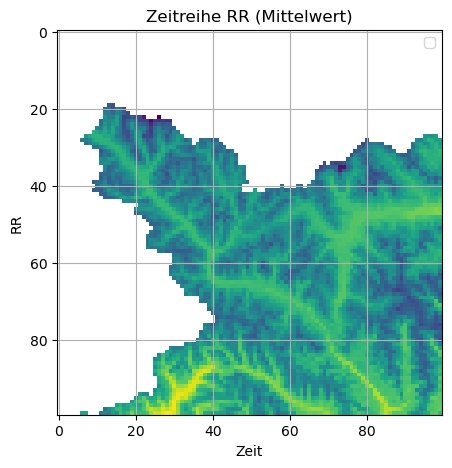

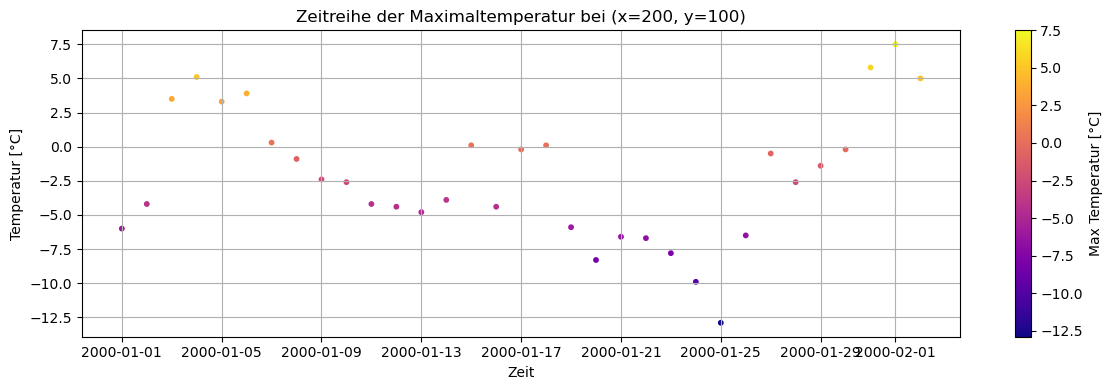

In [16]:
# Zeitfilter zuerst anwenden
ts = ds.sel(time=slice("2000-01-01", "2000-02-02"))['TX'][:, 100, 200]  # ergibt (zeit,)
time = ts['time'].values
values = ts.values  # viel kleinerer Bereich!

# Jetzt plotten
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
sc = plt.scatter(time, values, c=values, cmap='plasma', s=10)
plt.colorbar(sc, label="Max Temperatur [°C]")
plt.xlabel("Zeit")
plt.ylabel("Temperatur [°C]")
plt.title("Zeitreihe der Maximaltemperatur bei (x=200, y=100)")
plt.grid()
plt.tight_layout()
plt.show()



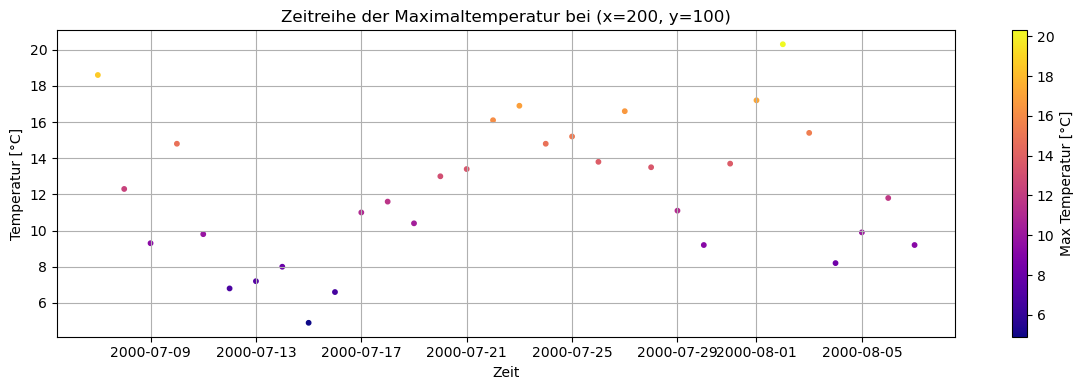

In [17]:
# Zeitfilter zuerst anwenden
ts = ds.sel(time=slice("2000-07-07", "2000-08-07"))['TX'][:, 100, 200]  # ergibt (zeit,)
time = ts['time'].values
values = ts.values  # viel kleinerer Bereich!

# Jetzt plotten
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
sc = plt.scatter(time, values, c=values, cmap='plasma', s=10)
plt.colorbar(sc, label="Max Temperatur [°C]")
plt.xlabel("Zeit")
plt.ylabel("Temperatur [°C]")
plt.title("Zeitreihe der Maximaltemperatur bei (x=200, y=100)")
plt.grid()
plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# Zeitfilter anwenden
ts = ds.sel(time=slice("2000-01-01", "2000-02-02"))['TX'][:, 100, 200]
time = ts['time'].values
values = ts.values

# Zeitwerte als Zahlen (für sauberen Plot)
time_num = np.arange(len(time))

# Liniensegmente erstellen
points = np.array([time_num, values]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Farbige Linie mit LineCollection
lc = LineCollection(segments, cmap='plasma', norm=plt.Normalize(values.min(), values.max()))
lc.set_array(values)
lc.set_linewidth(2)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.add_collection(lc)
ax.scatter(time_num, values, c=values, cmap='plasma', s=10)  # farbige Punkte
ax.set_xlim(time_num.min(), time_num.max())
ax.set_ylim(values.min() - 1, values.max() + 1)
ax.set_xticks(time_num[::max(1, len(time_num)//10)])
ax.set_xticklabels([str(t)[:10] for t in time[::max(1, len(time)//10)]], rotation=45)

plt.colorbar(lc, label="Max Temperatur [°C]")
plt.xlabel("Zeit")
plt.ylabel("Temperatur [°C]")
plt.title("Zeitreihe der Maximaltemperatur bei (x=200, y=100)")
plt.grid()
plt.tight_layout()
plt.show()


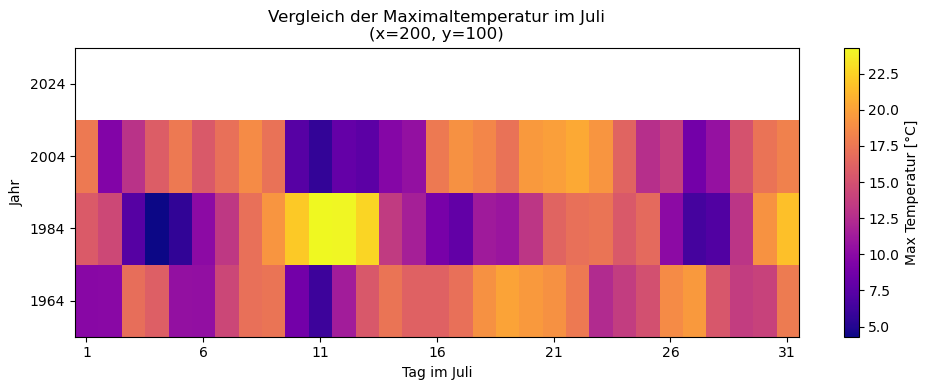

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Festen Punkt auswählen
x_pos = 200
y_pos = 100
years = [1964, 1984, 2004, 2024]
days_in_july = 31

# Temperaturzeitreihe am Punkt extrahieren (als DataArray)
ts_all = ds['TX'][:, y_pos, x_pos]  # shape: (time,)
times = ds['time'].values

# Als Pandas-DataFrame für einfaches Filtern
df = ts_all.to_dataframe(name="TX").reset_index()

# Juli-Werte für ausgewählte Jahre extrahieren
rows = []
for year in years:
    mask = (df['time'].dt.year == year) & (df['time'].dt.month == 7)
    df_july = df[mask].sort_values('time')
    
    # Falls z. B. 30 Tage → auffüllen mit NaN
    values = df_july['TX'].values
    values = np.pad(values, (0, days_in_july - len(values)), constant_values=np.nan)
    rows.append(values)

# 2D-Matrix: rows = Jahre, cols = Tage im Juli
data = np.array(rows)  # shape: (len(years), 31)

# Plot mit imshow
plt.figure(figsize=(10, 4))
im = plt.imshow(data, aspect="auto", cmap="plasma", origin="lower")
plt.colorbar(im, label="Max Temperatur [°C]")

plt.xticks(ticks=np.arange(0, 31, 5), labels=[str(i+1) for i in range(0, 31, 5)])
plt.yticks(ticks=np.arange(len(years)), labels=years)

plt.xlabel("Tag im Juli")
plt.ylabel("Jahr")
plt.title("Vergleich der Maximaltemperatur im Juli\n(x=200, y=100)")
plt.tight_layout()
plt.show()


TypeError: Invalid shape (4, 10, 31) for image data

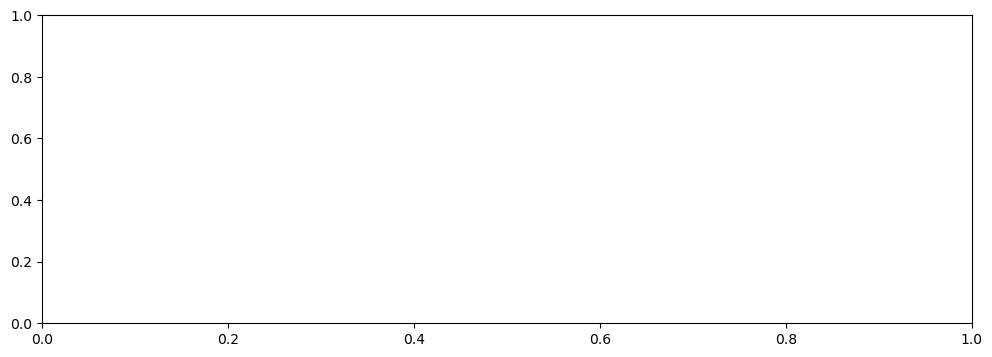

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fester Ort
x = 200
y = 100

# Jahre und Monat
years = [1964, 1984, 2004, 2024]
month = 7
days = 31

# Temperaturreihe am Punkt (lazy!)
ts = ds['TX'][:, y, x]
df = ts.to_dataframe(name="TX").reset_index()

# Jahresdaten vorbereiten
year_lines = []
for year in years:
    sub = df[
        (df['time'].dt.year == year) &
        (df['time'].dt.month == month)
    ].sort_values('time')
    
    vals = sub['TX'].values
    vals = np.pad(vals, (0, days - len(vals)), constant_values=np.nan)
    year_lines.append(vals)

# 2D: (Jahr, Tag)
data = np.array(year_lines)

# Normieren für Kontrast (optional)
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# Erstelle ein „Linienbild“ durch Strecken in Y
image = np.repeat(data[:, np.newaxis, :], 10, axis=1)  # shape: (n_years * 10, 31)

plt.figure(figsize=(12, 4))
im = plt.imshow(image, aspect="auto", cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)

# Achsen
plt.yticks(
    ticks=np.linspace(5, 10 * len(years) - 5, len(years)),
    labels=[str(y) for y in years]
)
plt.xticks(ticks=np.arange(0, 31, 5), labels=[str(d+1) for d in range(0, 31, 5)])
plt.xlabel("Tag im Juli")
plt.ylabel("Jahr")
plt.title(f"Maximaltemperatur im Juli bei (x={x}, y={y})")
plt.colorbar(im, label="Temperatur [°C]")
plt.tight_layout()
plt.show()
